# Processing pipelines for HER2-positive breast cancer

To facilitate accessibility and reproducibility of HER2-positive breast cancer, we provide detailed instructions for downloading both the spatial transcriptomics and single-cell reference, along with their preprocessing procedures. The HER2-positive breast cancer data used in this study were derived from the second section of tissue from subject G.


***
## Download the legacy dataset



**ST data**. A directory named `Datasets_raw_ST_G2` should be created. We download the data from https://github.com/almaan/her2st/tree/master/data. The `ST-cnts` directory contains gene expression matrices for all tissue sections, while the `ST-imgs` folder stores corresponding H&E stained images for each section. Spatial coordinates of spots within each section are archived in the `ST-spotfiles` folder. We utilized tissue section `G2` for this analysis. The H&E stained image (`HE_BT23903_C2a.jpg`), gene expression matrix (obtained by decompressing `G2.tsv.gz` as `ut_G2_stdata_filtered.tsv`), and spatial coordinates (`G2_selection.tsv`) were downloaded and stored in the directory: `Datasets_raw_ST_G2`. 

**Single-cell reference data**. The raw data `GSE176078_Wu_etal_2021_BRCA_scRNASeq.tar.gz` is downloaded from https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE176078. This folder contains four files, which are `count_matrix_barcodes.tsv`, `count_matrix_genes.tsv`, `count_matrix_sparse.mtx` and `metadata.csv`. Among them, `count_matrix_barcodes.tsv` contains the cell barcodes, `count_matrix_genes.tsv` contains the gene names, `count_matrix_sparse.mtx` contains the gene expression matrix stored in a sparse format, and `metadata.csv` contains the cell types as well as the sample numbers to which they belong. After downloading, these four files were placed in the  `Datasets_raw_breast_sc` directory.

And the processed results are saved in `ST_G2` as inputs of FINER model.

After completing the downloads, the directory structure should look like this:
```text
FINER/
└── data/
    └── ST_G2/
        ├── Datasets_raw_breast_sc/          
        │   ├── count_matrix_barcodes.tsv
        │   ├── count_matrix_genes.tsv
        │   ├── count_matrix_sparse.mtx
        │   └── metadata.csv
        └── Datasets_raw_ST_G2/                          
            ├── G2_selection.tsv
            ├── ut_G2_stdata_filtered.tsv
            └── HE_BT23903_C2a.jpg
```


***
## Preprocess the ST dataset

To enhance Cellpose's nuclear segmentation, we trimmed the empty regions around the histopathology images and corrected the spot coordinates accordingly.

In [ ]:
import os
import scanpy as sc
import numpy as np
import pandas as pd
import json
import anndata as ad
import cv2
from PIL import Image

tissue_name='ST_G2'


# Trim the empty regions around the histopathology images 
def pil2cv(image):
    ''' PIL -> OpenCV '''
    new_image = np.array(image, dtype=np.uint8)
    if new_image.ndim == 2:
        pass
    elif new_image.shape[2] == 3:
        new_image = cv2.cvtColor(new_image, cv2.COLOR_RGB2BGR)
    elif new_image.shape[2] == 4:
        new_image = cv2.cvtColor(new_image, cv2.COLOR_RGBA2BGRA)
    return new_image


Image.MAX_IMAGE_PIXELS = 1000000000
I = Image.open("./data/ST_G2/Datasets_raw_ST_G2/HE_BT23903_C2a.jpg")  ### 9863, 9326
I = pil2cv(I)

x_left = 0
x_right = 9000
y_top = 1000
y_bottom = 7500

I_crop = I[y_top:y_bottom, x_left:x_right]
cv2.imwrite("./data/ST_G2/G2.png", I_crop)



# Load legacy ST data
spots_exp_array = pd.read_csv('./data/ST_G2/Datasets_raw_ST_G2/ut_G2_stdata_filtered.tsv', sep='\t', index_col="Unnamed: 0")   
inter = spots_exp_array.index.values
crd = np.array([x.split("x") for x in inter]).astype(float)
spots_exp_array['x'] = crd[:,0] 
spots_exp_array['y'] = crd[:,1] 

locs = pd.read_csv('./data/ST_G2/Datasets_raw_ST_G2/G2_selection.tsv', sep='\t') ## spot locs with array 
spots_exp_locs = spots_exp_array.merge(locs, on=['x','y'], how='left')  ## exp with spot ary and locs

spot_exp = spots_exp_locs.iloc[:, :-7]
spot_locs = spots_exp_locs.loc[:, ['pixel_x', 'pixel_y']]
spot_locs['pixel_y'] = spot_locs['pixel_y'].values-y_top

# Save to h5ad file
spot_adata = ad.AnnData(
    X = spot_exp.values,  
    obs = spot_locs,      
    var = pd.DataFrame(index = spot_exp.columns)
)

spot_adata.obs_names = spot_exp.index.astype(str)  
spot_adata.var_names = spot_exp.columns.astype(str) 
spot_adata.write('./data/ST_G2/ST_adata.h5ad')

print(spot_adata)

***
## Preprocess the single-cell reference data

`count_matrix_sparse.mtx` contains 100,064 cells. Following the screening method of `CytoSPACE`, we screened the cells belonging to the `samples` of 'CID3921', 'CID45171', 'CID3838', 'CID3586', 'CID4066', 'CID44041', 'CID4465', 'CID4495', 'CID44971', 'CID44991', 'CID4513', 'CID4515', 'CID4523', 'CID3946', and 'CID3963'. And we removed the cells of the `'celltype_minor'` types 'Cycling T-cells' and 'Cycling_Myeloid'. Finally, we obtained the single-cell data that serves as the reference for `HER2-positive` breast cancer data.

In [ ]:
sc_gene_name = pd.read_csv('./data/ST_G2/Datasets_raw_breast_sc/count_matrix_genes.tsv', header=None, index_col=0, names=["gene_name"], sep='\t')   
sc_barcode = pd.read_csv('./data/ST_G2/Datasets_raw_breast_sc/count_matrix_barcodes.tsv', header=None, index_col=0, names=["gene_name"], sep='\t')


mtx_sparse = sc.read_mtx("./data/ST_G2/Datasets_raw_breast_sc/count_matrix_sparse.mtx")
mtx_dense = mtx_sparse.X.todense()


adata = ad.AnnData(X = mtx_dense.T)
adata.var_names = sc_gene_name.index.values
adata.obs_names = sc_barcode.index.values
print(adata)


df = pd.read_csv('./data/ST_G2/Datasets_raw_breast_sc/metadata.csv')
se_ids = ['CID3921', 'CID45171', 'CID3838', 'CID3586', 'CID4066', 'CID44041', 
         'CID4465', 'CID4495', 'CID44971', 'CID44991', 'CID4513', 'CID4515', 
         'CID4523', 'CID3946', 'CID3963']
filtered_df = df[df['orig.ident'].isin(se_ids)].copy()
del_type = ['Cycling T-cells', 'Cycling_Myeloid']
filtered_final = filtered_df[~filtered_df['celltype_minor'].isin(del_type)]
cells_to_keep = filtered_final['Unnamed: 0'].values

adata_se = adata[adata.obs_names.isin(cells_to_keep), :].copy()
adata_se.obs['cell_type'] = filtered_final['celltype_major'].values

sc.pp.normalize_total(adata_se, target_sum=1e4)
sc.pp.log1p(adata_se)

adata_se.write('./data/ST_G2/sc_adata_log.h5ad')

# Running FINER for HER2-positive breast cancer

***
## Prerequisites & Environment Setup

Before running the pipeline, ensure all required packages are installed following the setup instructions in `README.md`.

### Download the pretrained checkpoints
FINER uses pretrained histology encoders from **HIPT** and **RetCCL** during image feature construction. These checkpoint files can be downloaded using the links below:

- **HIPT ViT-256:** [`vit256_small_dino.pth`](https://github.com/mahmoodlab/HIPT/raw/refs/heads/master/HIPT_4K/Checkpoints/vit256_small_dino.pth)
- **HIPT ViT-4K:** [`vit4k_xs_dino.pth`](https://github.com/mahmoodlab/HIPT/raw/refs/heads/master/HIPT_4K/Checkpoints/vit4k_xs_dino.pth)
- **RetCCL:** [`best_ckpt.pth`](https://drive.google.com/drive/folders/1AhstAFVqtTqxeS9WlBpU41BV08LYFUnL?usp=sharing)  

Open the RetCCL Google Drive folder and download `best_ckpt.pth`.
After downloading the checkpoints and completing the preprocessing for both single-cell and spatial transcriptomics data, the directory structure should look like this:

```text
FINER/
├── checkpoints/
│   ├── vit256_small_dino.pth
│   ├── vit4k_xs_dino.pth
│   └── best_ckpt.pth
└── data/
    └── ST_G2/
        ├── Datasets_raw_breast_sc/          
        │   ├── count_matrix_barcodes.tsv
        │   ├── count_matrix_genes.tsv
        │   ├── count_matrix_sparse.mtx
        │   └── metadata.csv
        ├── sc_adata_log.h5ad                # Preprocessed single-cell reference data
        ├── spatial/                          
        │   ├── tissue_hires_image.png
        │   ├── tissue_positions_list.csv
        │   └── filtered_feature_bc_matrix.h5
        └── ST_adata.h5ad                    # Preprocessed spatial transcriptomics data
```

## Cellular Identity Reconstruction
FINER requires spot-level cell type proportion estimates as input. You can generate these deconvolution results using various tools (such as PANDA; please refer to the official PANDA tutorial https://github.com/Zhangxf-ccnu/PANDA for step-by-step guidance). For this tutorial, the PANDA-based deconvolution results used in our analysis are provided in the accompanying [Zenodo archive](https://doi.org/10.5281/zenodo.22234790) located at `data/ST_G2/deconv_results.csv`. Users may also use their own deconvolution results by saving the resulting proportion matrix as `deconv_results.csv` inside the corresponding sample folder (i.e., `./data/ST_G2/deconv_results.csv`).

### Cellular Unit Identification

Before extracting image features, FINER requires single-cell centroid coordinates. While various cell segmentation tools can be seamlessly integrated into this pipeline, we demonstrate the workflow using [Cellpose](https://github.com/MouseLand/cellpose) (version 2.2.3) here. To handle large Whole Slide Images (WSIs), the image is dynamically tiled into patches, segmented, and the resulting cell centroids are mapped back to global pixel coordinates, saving the output as `cell_segmented_coords.csv`.


In [ ]:
%%bash
python -m finer.nuclei_segment \
    --tissue_name "ST_G2" \
    --img_name "G2.png" \
    --patch_size 5000 5000 \
    --flow_threshold 1.0 \
    --diameter 10

### Image Feature Construction

This step processes the H&E image alongside cell segmentation coordinates to extract multi-scale visual embeddings via HIPT and RetCCL models.


In [ ]:
%%bash
python -m finer.feature_construction \
    --tissue_name "ST_G2" \
    --img_path "./data/ST_G2/G2.png" \
    --spot_diameter_pixel 146 \
    --spot_diameter_um 100 \
    --checkpoint_path "./checkpoints"

### Cellular Identity Reconstruction

In [ ]:
%%bash
python -m finer.identity_reconstruction \
    --tissue_name "ST_G2" \
    --spot_radius 73 

Through this cell-identity reconstruction process, the predicted cellular identity assignments are obtained as shown below:

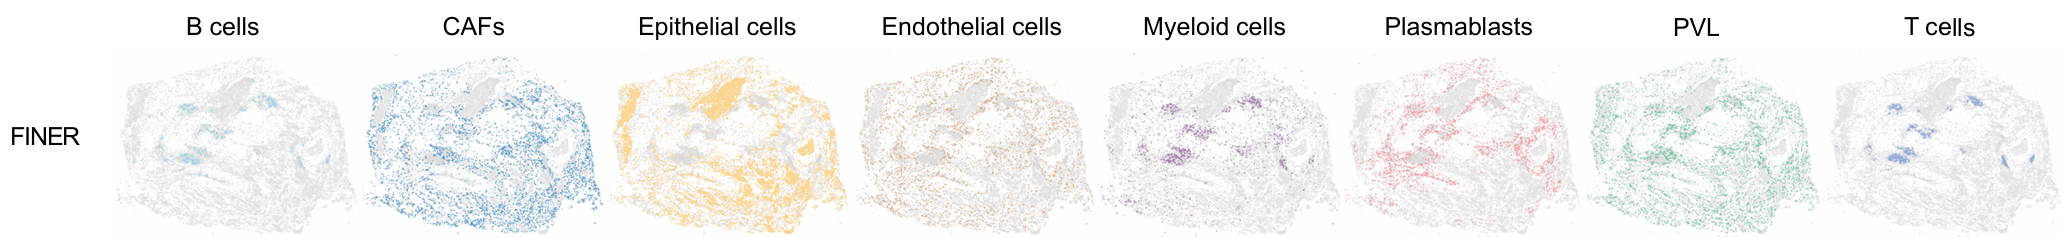 

## Cellular Expression Reconstruction

Finally, FINER reconstructs tissue-wide cell-by-gene map using the cellular scaffold (`cellular_scaffold.h5ad`) obtained from `Cellular Identity Reconstruction`, log-transformed single-cell reference `sc_adata_log.h5ad`, spot-based spatialtranscriptome `ST_adata.h5ad`, and morphological features: `hipt_sub_feats.npy` and `resccl_feats.npy`. The output is saved as `finer_reconstructed.h5ad`.

In [ ]:
%%bash
python -m finer.expression_reconstruction \
    --tissue_name "ST_G2" \
    --spot_radius 73 

Through the cellular expression reconstruction process, the reconstructed single-cell gene expression profiles are obtained as shown below:

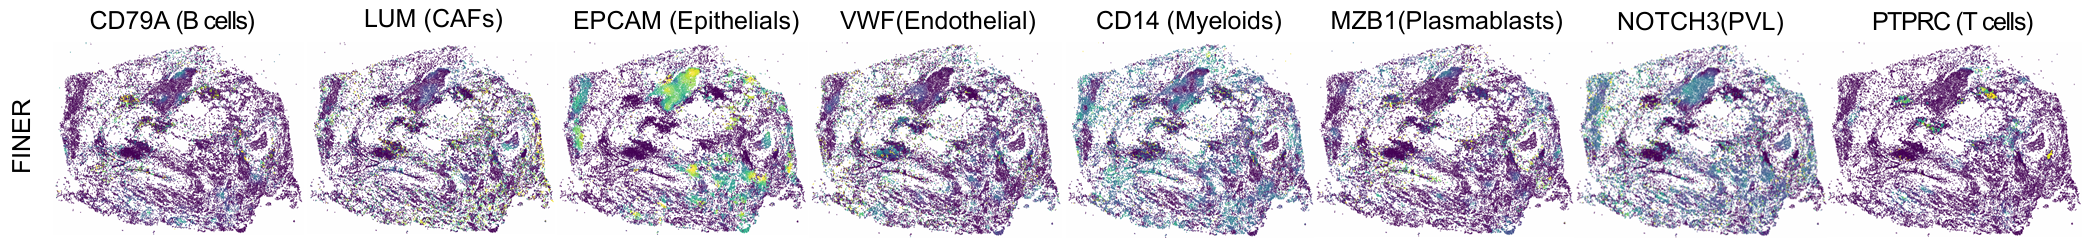

# Context-associated tumour heterogeneity in HER2-positive breast cancer

***
In this section, we demonstrate how to analyze context-associated tumour heterogeneity in HER2-positive breast cancer using the single-cell identities and spatial expression profiles reconstructed by FINER (`finer_reconstructed.h5ad`).

## Defining Experimental Utility Functions
We first define (or import) the following helper functions:

In [ ]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
from scipy import sparse as sp
from scipy.spatial import Delaunay, QhullError, cKDTree
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
import gseapy as gp


def build_delaunay_graph(coords, dmax=None, random_state=0):
    coords = np.asarray(coords, dtype=np.float64)
    n = coords.shape[0]
    if n < 3:
        return sp.csr_matrix((n, n), dtype=np.float32)
    rng = np.random.default_rng(random_state)
    coords_jitter = coords + rng.normal(0, 1e-6, size=coords.shape)
    try:
        tri = Delaunay(coords_jitter)
    except QhullError:
        return sp.csr_matrix((n, n), dtype=np.float32)
    simplices = tri.simplices
    edges = np.vstack([simplices[:, [0, 1]], simplices[:, [1, 2]], simplices[:, [2, 0]]])
    edges = np.sort(edges, axis=1)
    edges = np.unique(edges, axis=0)
    if dmax is not None and edges.shape[0] > 0:
        dist = np.linalg.norm(coords[edges[:, 0]] - coords[edges[:, 1]], axis=1)
        edges = edges[dist <= float(dmax)]
    if edges.shape[0] == 0:
        return sp.csr_matrix((n, n), dtype=np.float32)
    row = np.concatenate([edges[:, 0], edges[:, 1]])
    col = np.concatenate([edges[:, 1], edges[:, 0]])
    data = np.ones(len(row), dtype=np.float32)
    A = sp.csr_matrix((data, (row, col)), shape=(n, n), dtype=np.float32)
    A.eliminate_zeros()
    return A


def onehot_cell_types(cell_type_labels, cell_type_order):
    labels = np.asarray(cell_type_labels).astype(str)
    type_to_id = {t: i for i, t in enumerate(cell_type_order)}
    n, k = len(labels), len(cell_type_order)
    onehot = np.zeros((n, k), dtype=np.float32)
    valid = np.array([x in type_to_id for x in labels])
    idx = np.where(valid)[0]
    type_ids = np.array([type_to_id[labels[i]] for i in idx], dtype=int)
    onehot[idx, type_ids] = 1.0
    return onehot


def add_graph_environment_features(adata, cell_type_order, dmax, random_state=0, scale=True):
    coords = adata.obsm["spatial"]
    cell_type_labels = adata.obs["cell_type"].values
    A = build_delaunay_graph(coords, dmax=dmax, random_state=random_state)
    onehot = onehot_cell_types(cell_type_labels, cell_type_order)
    counts = A @ onehot
    denom = counts.sum(axis=1, keepdims=True)
    with np.errstate(divide="ignore", invalid="ignore"):
        props = np.divide(counts, denom, out=np.zeros_like(counts), where=denom > 0)
    if scale:
        X_scaled = StandardScaler().fit_transform(props).astype(np.float32)
    else:
        X_scaled = props.copy().astype(np.float32)
    adata.obsm["X_env_raw"] = props.astype(np.float32)
    adata.obsm["X_env"] = X_scaled.astype(np.float32)
    return adata



def cluster_target_niches(adata, target_cell_type, n_niche, env_key="X_env", cluster_col="niche_cluster", random_state=32):
    adata.obs[cluster_col] = "Other"
    mask = adata.obs["cell_type"].astype(str).values == target_cell_type
    idx = np.where(mask)[0]
    if len(idx) == 0:
        raise ValueError(f"Target cell type '{target_cell_type}' was not found in the dataset")
    X = np.asarray(adata.obsm[env_key][idx], dtype=np.float32)
    km = KMeans(
        n_clusters=n_niche,
        init="k-means++",
        n_init=50,
        max_iter=500,
        random_state=random_state,
    )
    labels = km.fit_predict(X).astype(str)
    adata.obs.iloc[idx, adata.obs.columns.get_loc(cluster_col)] = labels
    adata.obs[cluster_col] = adata.obs[cluster_col].astype("category")
    return adata




def find_niche_specific_markers(adata, target_cell_type, cluster_col="niche_cluster", top_n_markers=10):
    adata_target = adata[adata.obs["cell_type"] == target_cell_type].copy()
    if "log1p" not in adata_target.uns:
        sc.pp.normalize_total(adata_target, target_sum=1e4)
        sc.pp.log1p(adata_target)
    sc.tl.rank_genes_groups(
        adata_target, 
        groupby=cluster_col, 
        method="wilcoxon", 
        key_added="niche_de"
    )
    result_df = sc.get.rank_genes_groups_df(adata_target, group=None, key="niche_de")
    filtered_df = result_df[(result_df["logfoldchanges"] > 0.5) & (result_df["pvals_adj"] < 0.05)]
    top_markers = filtered_df.groupby("group").head(top_n_markers).copy()
    print(top_markers[["group", "names", "logfoldchanges", "pvals_adj"]])
    return top_markers, adata_target


def run_enrichr_for_each_beta_cluster(
    de_df,
    out_dir="./data/",
    gene_col="names",
    cluster_col="cluster",
    top_n=200,
    libraries=("MSigDB_Hallmark_2020", "KEGG_2021_Human", "GO_Biological_Process_2021"),
):
    os.makedirs(out_dir, exist_ok=True)
    clusters = de_df[cluster_col].unique().tolist()
    all_res = []
    for c in clusters:
        genes = de_df.loc[de_df[cluster_col] == c, gene_col].head(top_n).dropna().astype(str).tolist()
        genes = [g for g in genes if g != "nan"]
        enr = gp.enrichr(
            gene_list=genes,
            gene_sets=list(libraries),
            organism="Human",  
            outdir=None,
            cutoff=0.05
        )
        r = enr.results.copy()
        r = r[r["P-value"] < 0.05]
        r["cluster"] = c
        r.to_csv(f"{out_dir}/enrichr_{c}.csv", index=False)
        all_res.append(r)
    all_res_df = pd.concat(all_res, ignore_index=True) if len(all_res) else pd.DataFrame()
    return all_res_df


## Executing Heterogeneity Analysis on HER2-positive breast cancer

In [ ]:
os.chdir('./data/ST_G2/') 

adata = ad.read('finer_reconstructed.h5ad')

cell_type_order = sorted(adata.obs["cell_type"].unique().tolist())
adata = add_graph_environment_features(
    adata, 
    cell_type_order=cell_type_order, 
    dmax = 73 * 4.0, 
    random_state=32,
    scale=True
)

adata = cluster_target_niches(
    adata, 
    target_cell_type="Cancer Epithelial", 
    n_niche=3,  
    env_key="X_env",   
    random_state=32,
    cluster_col="niche_cluster"
)

By visualizing the spatial niches of epithelial cells identified through clustering, we obtain the results shown below:

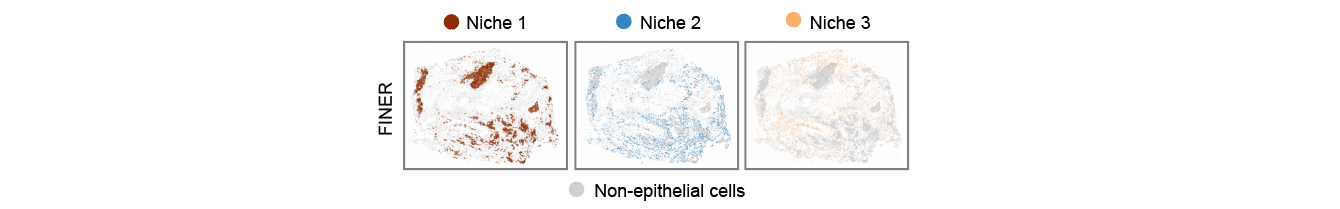

Subsequently, differential expression analysis is performed among the three niches to identify niche-associated marker genes, followed by pathway enrichment analysis.

In [ ]:
top_markers, adata_target = find_niche_specific_markers(
    adata, 
    target_cell_type="Cancer Epithelial", 
    top_n_markers=100
)

enrichr_all = run_enrichr_for_each_beta_cluster(
    de_df=top_markers,  
    out_dir="./data/ST_G2/",
    gene_col="names",      
    cluster_col="group",   
    libraries=[
        "MSigDB_Hallmark_2020"
    ], 
    top_n=20         
)

To highlight key biological processes, the top 3 enriched pathways per niche are selected and plotted as follows:

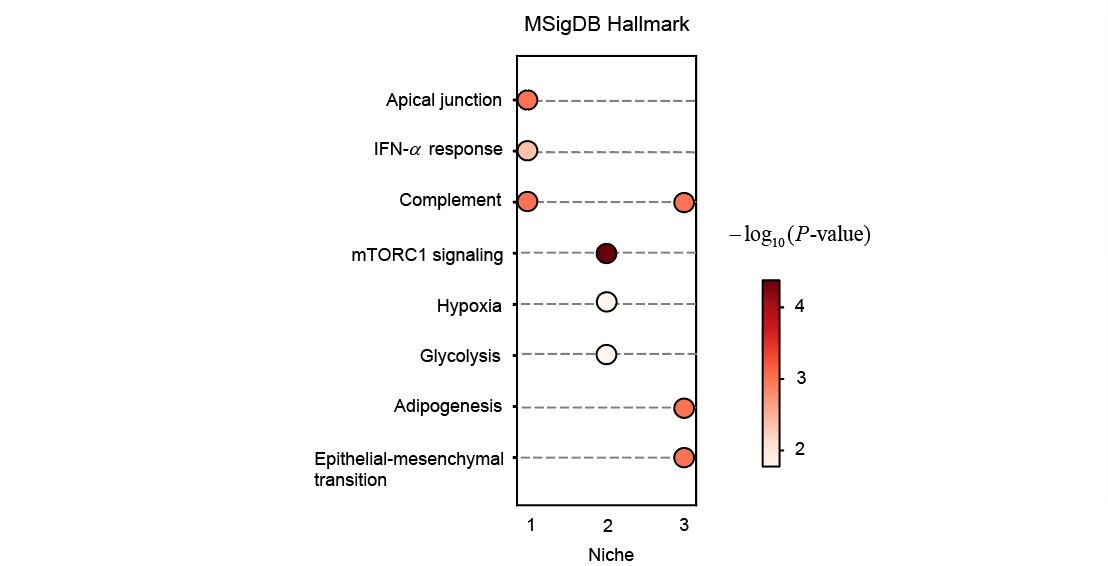

Additionally, the expression pattern of a representative gene associated with each niche is visualized as shown below:

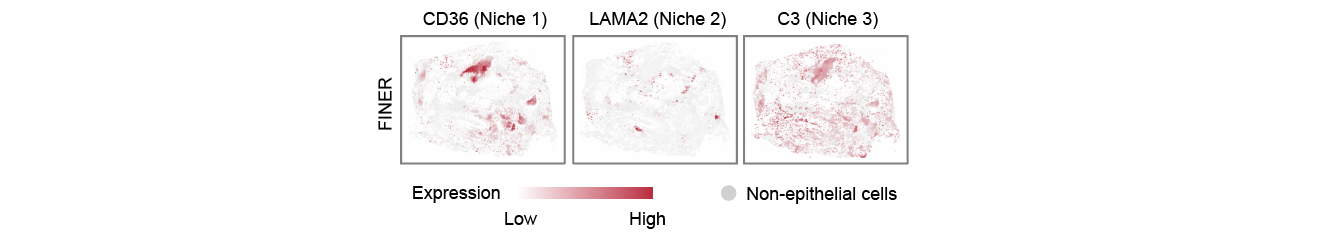